In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler

In [2]:
df = pd.read_csv("networkTraffic.csv")
df = df.replace('?', np.nan) # "There remain features with missing value, with missing values indicated by the character symbol '?'"

print("\nFirst 5 rows:")
print(df.head())
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns)
#print("\nData types:")
#print(df.dtypes)


First 5 rows:
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp     NaN   INT      2      0     496       0   
1   2  0.000008   udp     NaN   INT      2      0    1762       0   
2   3  0.000005   udp     NaN   INT      2      0    1068       0   
3   4  0.000006   udp     NaN   INT      2      0     900       0   
4   5  0.000010   udp     NaN   INT      2      0    2126       0   

          rate  ...  ct_src_dport_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  \
0   90909.0902  ...                 1                 1               2   
1  125000.0003  ...                 1                 1               2   
2  200000.0051  ...                 1                 1               3   
3  166666.6608  ...                 2                 1               3   
4  100000.0025  ...                 2                 1               3   

   is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  \
0             0           0                 0 

In [3]:
# Split data
X = df.drop(columns=["attack_cat"])
y = df["attack_cat"]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1111111111, random_state=42, stratify=y_train_val)
print(f"X_train: {len(X_train)}, X_val: {len(X_val)}, X_test: {len(X_test)}")

X_train: 206137, X_val: 25768, X_test: 25768


In [4]:
# missing values
missing = pd.DataFrame({
    "Missing": X_train.isna().sum(),
    "Percentage": X_train.isna().mean() * 100
})
print(missing)

                   Missing  Percentage
id                       0    0.000000
dur                      0    0.000000
proto                    0    0.000000
service             113104   54.868364
state                    0    0.000000
spkts                    0    0.000000
dpkts                    0    0.000000
sbytes                   0    0.000000
dbytes                   0    0.000000
rate                     0    0.000000
sttl                     0    0.000000
dttl                     0    0.000000
sload                    0    0.000000
dload                    0    0.000000
sloss                    0    0.000000
dloss                    0    0.000000
sinpkt                   0    0.000000
dinpkt                   0    0.000000
sjit                     0    0.000000
djit                     0    0.000000
swin                     0    0.000000
stcpb                    0    0.000000
dtcpb                    0    0.000000
dwin                     0    0.000000
tcprtt                   

In [ ]:
# drop service as it has 141321 values missing (more than half of its values)
#X_train = X_train.drop(columns=["service"]) 
#X_val = X_val.drop(columns=["service"]) 
#X_test = X_test.drop(columns=["service"]) 
# TODO Instead of dropping service it should be kept with nan as its own category. Which is natively done by OneHotEncoder

In [6]:
unique_features = [
    col for col in X_train.columns
    if X_train[col].nunique(dropna=False) == len(X_train)
]

print("Features with unique value for every observation:")
print(unique_features)

Features with unique value for every observation:
['id']


In [7]:
# drop id as it has a unique value for every row
X_train = X_train.drop(columns=["id"]) 
X_val = X_val.drop(columns=["id"]) 
X_test = X_test.drop(columns=["id"]) 

In [8]:
# cardinality
print(f"Unique values: {X_train.nunique(dropna=False)}")

Unique values: dur                  90411
proto                  133
service                 13
state                   11
spkts                  589
dpkts                  567
sbytes                8110
dbytes                7516
rate                 94443
sttl                    13
dttl                     9
sload                99139
dload                94736
sloss                  438
dloss                  434
sinpkt               93257
dinpkt               89820
sjit                 94928
djit                 93031
swin                    19
stcpb                92579
dtcpb                92325
dwin                    17
tcprtt               53571
synack               48986
ackdat               45816
smean                 1362
dmean                 1353
trans_depth             13
response_body_len     2478
ct_srv_src              57
ct_state_ttl             7
ct_dst_ltm              52
ct_src_dport_ltm        52
ct_dst_sport_ltm        34
ct_dst_src_ltm          58
is_ftp_login 

In [9]:
# categorical: -> one-hot-encoding for knn (proto only top 9 categories and rest in 10th category)
#  proto (133), service (13), state (11) -> Strings
#  attack_cat (10), is_ftp_login (4) -> Numbers
#  is_sm_ips_ports (2) -> True/False

# numerical:
#  dur (109945), spkts (646), dpkts (627), sbytes (9382), dbytes (8653), rate (115763), sload (121356), dload (116380), sloss (490), dloss (476), sinpkt (114318), dinpkt (110270)
#  sjit (117101), djit (114861), stcpb (114473), dtcpb (114187), tcprtt (63878), synack (57366), ackdat (53248), smean (1377), dmean (1362), trans_depth (14), response_body_len (2819),
#  ct_srv_src (57), ct_dst_ltm (52), ct_src_dport_ltm (52), ct_dst_sport_ltm (35), ct_dst_src_ltm (58), ct_flw_http_mthd (11), ct_src_ltm (52), ct_srv_dst (57)
#  sttl (13), dttl (9), swin (22), dwin (19), ct_state_ttl (7), ct_ftp_cmd (4)

categorical_features = [
    'proto', 'service', 'state',  
    'is_ftp_login', 'is_sm_ips_ports'           
]

numerical_features = [
    'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
    'sloss', 'dloss', 'sinpkt', 'dinpkt',
    'sjit', 'djit', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat',
    'smean', 'dmean', 'trans_depth', 'response_body_len',
    'ct_srv_src', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
    'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst',
    'sttl', 'dttl', 'swin', 'dwin', 'ct_state_ttl', 'ct_ftp_cmd'
]

print("Categorical features:")
print(categorical_features)
print("\nNumerical features:")
print(numerical_features)

Categorical features:
['proto', 'service', 'state', 'is_ftp_login', 'is_sm_ips_ports']

Numerical features:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'sttl', 'dttl', 'swin', 'dwin', 'ct_state_ttl', 'ct_ftp_cmd']


In [10]:
# summary of categorical and numerical values
cat_summary = X_train[categorical_features].describe(include="all").T
print(cat_summary)

numeric_summary = X_train[numerical_features].describe().T
print(numeric_summary)

                    count unique  top   freq      mean       std  min  25%  \
proto              206137    133  tcp  98491       NaN       NaN  NaN  NaN   
service             93033     12  dns  54927       NaN       NaN  NaN  NaN   
state              206137     11  FIN  93811       NaN       NaN  NaN  NaN   
is_ftp_login     206137.0    NaN  NaN    NaN  0.012826  0.116174  0.0  0.0   
is_sm_ips_ports  206137.0    NaN  NaN    NaN  0.014146  0.118093  0.0  0.0   

                 50%  75%  max  
proto            NaN  NaN  NaN  
service          NaN  NaN  NaN  
state            NaN  NaN  NaN  
is_ftp_login     0.0  0.0  4.0  
is_sm_ips_ports  0.0  0.0  1.0  
                      count          mean           std   min           25%  \
dur                206137.0  1.236573e+00  5.937105e+00   0.0      0.000008   
spkts              206137.0  1.963065e+01  1.327327e+02   1.0      2.000000   
dpkts              206137.0  1.847062e+01  1.147727e+02   0.0      0.000000   
sbytes           

In [11]:
# Bucket proto using X_train only, then apply the same mapping everywhere TODO is 10 buckets enough? Should other One-hot-encoded features also be caped?
top_protocols = X_train['proto'].value_counts().nlargest(9).index.tolist()
X_train['proto'] = X_train['proto'].where(X_train['proto'].isin(top_protocols), 'other')
X_val['proto'] = X_val['proto'].where(X_val['proto'].isin(top_protocols), 'other')
X_test['proto'] = X_test['proto'].where(X_test['proto'].isin(top_protocols), 'other')

In [12]:
# outliers:
outlier_results = []

for col in numerical_features:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()

    outlier_results.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower,
        "Upper bound": upper,
        "Outliers": outliers,
        "Outlier %": outliers / len(X_train) * 100
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary = outlier_summary.sort_values(
    "Outlier %",
    ascending=False
)

print(outlier_summary)

              Feature            Q1            Q3           IQR   Lower bound  \
7               dload      0.000000  2.234121e+04  2.234121e+04 -3.351182e+04   
25   ct_src_dport_ltm      1.000000  4.000000e+00  3.000000e+00 -3.500000e+00   
26   ct_dst_sport_ltm      1.000000  3.000000e+00  2.000000e+00 -2.000000e+00   
27     ct_dst_src_ltm      1.000000  8.000000e+00  7.000000e+00 -9.500000e+00   
24         ct_dst_ltm      1.000000  6.000000e+00  5.000000e+00 -6.500000e+00   
4              dbytes      0.000000  1.060000e+03  1.060000e+03 -1.590000e+03   
9               dloss      0.000000  2.000000e+00  2.000000e+00 -3.000000e+00   
1               spkts      2.000000  1.200000e+01  1.000000e+01 -1.300000e+01   
30         ct_srv_dst      2.000000  1.100000e+01  9.000000e+00 -1.150000e+01   
20              dmean      0.000000  8.900000e+01  8.900000e+01 -1.335000e+02   
19              smean     57.000000  1.000000e+02  4.300000e+01 -7.500000e+00   
3              sbytes    114

In [13]:
# models should predict and identify if something is a attackType and which one: normal, Fuzzers, ... see attack_category_map.csv

In [14]:
### k-NN
numerical_features_knn = numerical_features
X_train_knn = X_train.copy()
X_val_knn = X_val.copy()
X_test_knn = X_test.copy()
y_train_knn = y_train.copy()
y_val_knn = y_val.copy()
y_test_knn = y_test.copy()

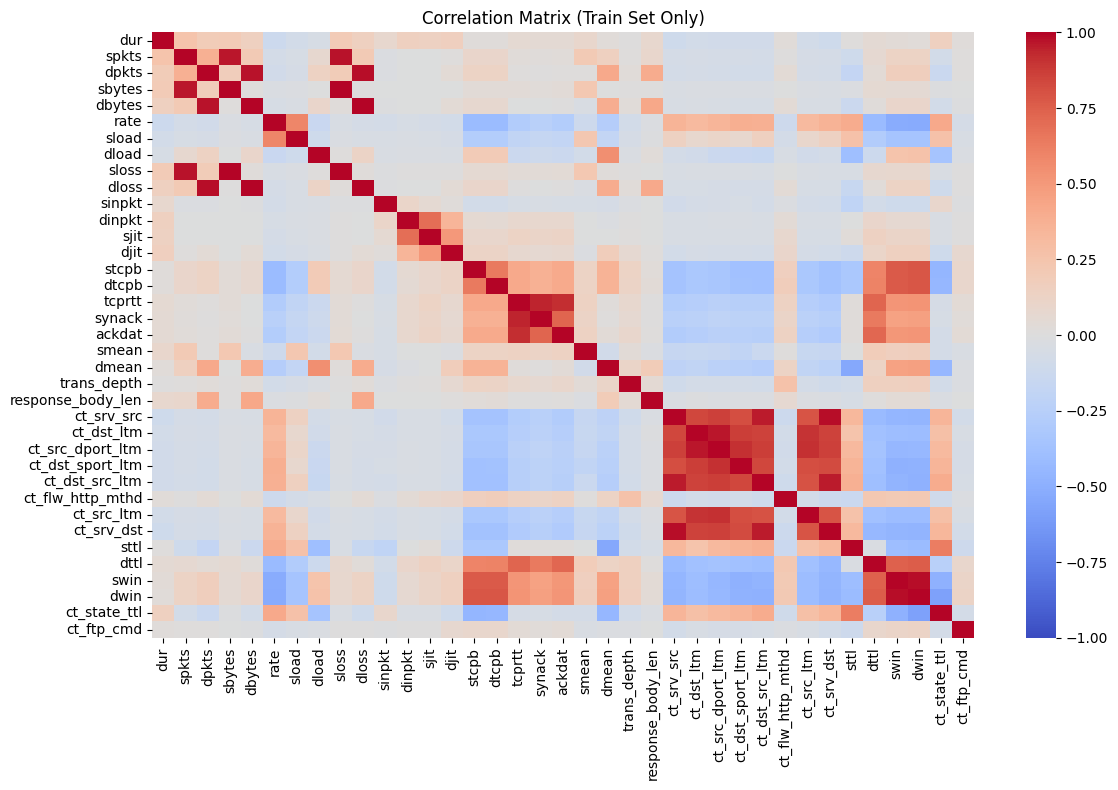

,Feature 1,Feature 2,Correlation
142,dbytes,dloss,0.996953
109,sbytes,sloss,0.995606
77,dpkts,dloss,0.981636
660,swin,dwin,0.980717
581,ct_srv_src,ct_srv_dst,0.979671
72,dpkts,dbytes,0.975881
42,spkts,sloss,0.970318
37,spkts,sbytes,0.962584
588,ct_dst_ltm,ct_src_dport_ltm,0.961200
623,ct_dst_src_ltm,ct_srv_dst,0.960693


In [15]:
# Correlation matrix computed on X_train_knn only
correlation_matrix = X_train_knn[numerical_features_knn].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix (Train Set Only)")
plt.tight_layout()
plt.show()

threshold = 0.9
corr_pairs = (correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)).stack().reset_index())
corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
high_correlations = corr_pairs[corr_pairs["Correlation"].abs() >= threshold].sort_values("Correlation", key=lambda x: x.abs(), ascending=False)
display(high_correlations)

In [16]:
correlating_features = ["dloss", "sloss", "dwin", "dpkts", "ct_srv_src", "spkts", "ct_dst_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm", "ct_src_ltm", "tcprtt"]

X_train_knn = X_train_knn.drop(columns=correlating_features)
X_val_knn = X_val_knn.drop(columns=correlating_features)
X_test_knn = X_test_knn.drop(columns=correlating_features)

numerical_features_knn = [f for f in numerical_features_knn if f not in correlating_features]

In [17]:
# numeric scales of values: not robust -> scaling for numerical features and one-hot-encoding for categorical features
preprocessor_knn = ColumnTransformer(transformers=[
    #("num", StandardScaler(), numerical_features_knn),
    ("num", RobustScaler(), numerical_features_knn), # brings outliers closer to the other values
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

X_train_processed_knn = preprocessor_knn.fit_transform(X_train_knn)
X_val_processed_knn = preprocessor_knn.transform(X_val_knn)
X_test_processed_knn = preprocessor_knn.transform(X_test_knn)

# skewed class distribution: 
# smote = SMOTE(random_state=42)
class_counts = y_train_knn.value_counts()
majority_size = class_counts.max()
sampling_strategy = {cls: max(count, int(majority_size * 0.3)) for cls, count in class_counts.items()}
smote = SMOTE(random_state=42, sampling_strategy=sampling_strategy)
X_train_resampled_knn, y_train_resampled_knn = smote.fit_resample(X_train_processed_knn, y_train_knn)

In [18]:
# hyperparamater testing
knn_results = []

for k in [3, 5, 7, 11, 15, 21, 31]:
    knn = KNeighborsClassifier(n_neighbors=k, weights="distance")
    knn.fit(X_train_resampled_knn, y_train_resampled_knn)

    y_val_pred_knn = knn.predict(X_val_processed_knn)
    macro_f1 = f1_score(y_val, y_val_pred_knn, average="macro")
    weighted_f1 = f1_score(y_val, y_val_pred_knn, average="weighted")

    knn_results.append({"n_neighbors": k, "macro_f1": macro_f1, "weighted_f1": weighted_f1})
    print(f"k={k}: macro F1={macro_f1:.3f}, weighted F1={weighted_f1:.3f}")

knn_results_df = pd.DataFrame(knn_results)
print(knn_results_df.sort_values("macro_f1", ascending=False))

k=3: macro F1=0.496, weighted F1=0.777
k=5: macro F1=0.502, weighted F1=0.784
k=7: macro F1=0.497, weighted F1=0.783
k=11: macro F1=0.493, weighted F1=0.785
k=15: macro F1=0.489, weighted F1=0.786
k=21: macro F1=0.485, weighted F1=0.784
k=31: macro F1=0.483, weighted F1=0.782
   n_neighbors  macro_f1  weighted_f1
1            5  0.501917     0.784048
2            7  0.496835     0.783497
0            3  0.496267     0.776823
3           11  0.492994     0.784880
4           15  0.488594     0.785541
5           21  0.485096     0.783814
6           31  0.482610     0.782440


In [19]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train_resampled_knn, y_train_resampled_knn)

KNeighborsClassifier(weights='distance')

In [ ]:
# Evaluation on train
y_train_pred_knn = knn.predict(X_train_processed_knn)
print("Train Set Performance")
print(classification_report(y_train_knn, y_train_pred_knn))

# Evaluation on validation
y_val_pred_knn = knn.predict(X_val_processed_knn)
print("Validation Set Performance")
print(classification_report(y_val_knn, y_val_pred_knn))

In [ ]:
joblib.dump(knn, "knn_model.pkl")
joblib.dump(preprocessor_knn, "preprocessor_knn.pkl")

['preprocessor_knn.pkl']

In [ ]:
#knn = joblib.load("knn_model.pkl")
#preprocessor = joblib.load("preprocessor_knn.pkl")

In [ ]:
### Classification tree
X_train_tree = X_train.copy()
X_val_tree = X_val.copy()
X_test_tree = X_test.copy()
y_train_tree = y_train.copy()
y_val_tree = y_val.copy()
y_test_tree = y_test.copy()

X_train: 206137, X_val: 25768, X_test: 25768


In [ ]:
# OneHotEncoding for categorical features
preprocessor_tree = ColumnTransformer(transformers=[
    ("num", "passthrough", numerical_features),
    # ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

X_train_processed_tree = preprocessor_tree.fit_transform(X_train_tree)
X_val_processed_tree = preprocessor_tree.transform(X_val_tree)
X_test_processed_tree = preprocessor_tree.transform(X_test_tree)

# DATA QUALITY ISSUES:
# correlation: robust
# outliers: robust
# numeric scales of values: robust
# skewed class distribution: sensitive -> must be fixed -> class_weight="balanced" -> increases weight of loss function for minority classes

Number of alpha values to try: 9322
[ 0.00000000e+00 -1.08420217e-19 -1.08420217e-19 -1.08420217e-19
 -5.42101086e-20 -5.42101086e-20 -2.87991202e-20 -2.71050543e-20
 -2.71050543e-20 -1.01643954e-20] ... [0.02344453 0.02364964 0.03908942 0.04904749 0.0839515 ]
    ccp_alpha  train_f1    val_f1  n_nodes
45   0.000018  0.646509  0.584296     2885
46   0.000024  0.638002  0.583828     2225
47   0.000032  0.627125  0.583471     1677
44   0.000016  0.647206  0.577344     3551
48   0.000049  0.594854  0.570674      981
38   0.000009  0.682591  0.570110     7681
37   0.000009  0.685333  0.570091     8295
36   0.000008  0.688156  0.569343     8871
35   0.000008  0.691634  0.569150     9529
34   0.000007  0.693983  0.568067    10195


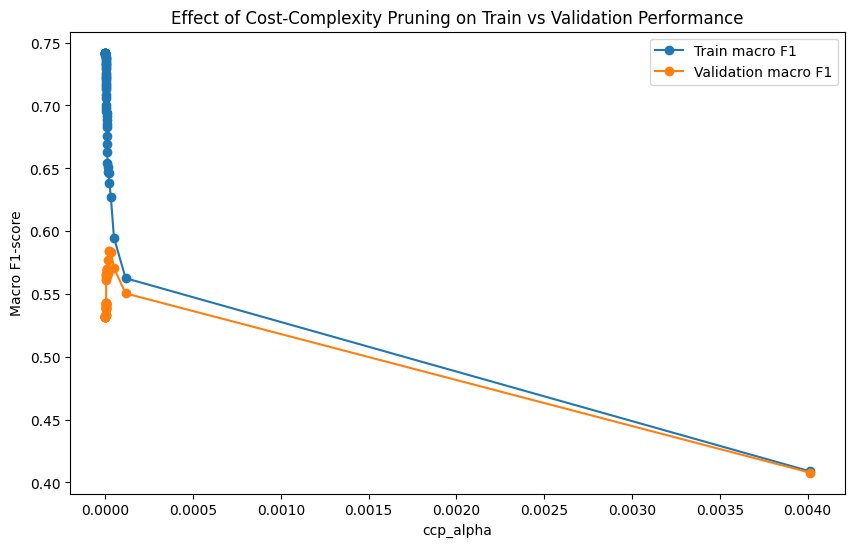

In [ ]:
# Pruning for Decision Tree with hyperparamater testing
tree_full = DecisionTreeClassifier(class_weight="balanced", random_state=42)
path = tree_full.cost_complexity_pruning_path(X_train_processed_tree, y_train_tree)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Number of alpha values to try: {len(ccp_alphas)}")
print(ccp_alphas[:10], "...", ccp_alphas[-5:])

# Test different alpha values: here 50 -> alpha is price for complexity
alphas_to_try = ccp_alphas[::max(1, len(ccp_alphas)//50)]

results = []
for alpha in alphas_to_try:
    clf = DecisionTreeClassifier(class_weight="balanced", random_state=42, ccp_alpha=alpha)
    clf.fit(X_train_processed_tree, y_train_tree)

    train_f1 = f1_score(y_train_tree, clf.predict(X_train_processed_tree), average="macro")
    val_f1 = f1_score(y_val_tree, clf.predict(X_val_processed_tree), average="macro")
    n_nodes = clf.tree_.node_count

    results.append({"ccp_alpha": alpha, "train_f1": train_f1, "val_f1": val_f1, "n_nodes": n_nodes})

results_df = pd.DataFrame(results)
print(results_df.sort_values("val_f1", ascending=False).head(10))

plt.figure(figsize=(10, 6))
plt.plot(results_df["ccp_alpha"], results_df["train_f1"], marker="o", label="Train macro F1")
plt.plot(results_df["ccp_alpha"], results_df["val_f1"], marker="o", label="Validation macro F1")
plt.xlabel("ccp_alpha")
plt.ylabel("Macro F1-score")
plt.title("Effect of Cost-Complexity Pruning on Train vs Validation Performance")
plt.legend()
plt.show()

In [ ]:
best_alpha = results_df.sort_values("val_f1", ascending=False).iloc[0]["ccp_alpha"]
print("Best alpha:", best_alpha)

tree_pruned = DecisionTreeClassifier(class_weight="balanced", random_state=42, ccp_alpha=best_alpha)
tree_pruned.fit(X_train_processed_tree, y_train_tree)

print("Train macro F1:", f1_score(y_train_tree, tree_pruned.predict(X_train_processed_tree), average="macro"))
print("Val macro F1:", f1_score(y_val_tree, tree_pruned.predict(X_val_processed_tree), average="macro"))
print("Number of nodes:", tree_pruned.tree_.node_count)

Best alpha: 1.8491003540495018e-05
Train macro F1: 0.6465088520347966
Val macro F1: 0.5842964239499002
Number of nodes: 2885


In [ ]:
# Evaluation on train
y_train_pred_tree = tree_pruned.predict(X_train_processed_tree)
print("Train Set Performance")
print(classification_report(y_train_tree, y_train_pred_tree))

# Evaluation on validation
y_val_pred_tree = tree_pruned.predict(X_val_processed_tree)
print("Validation Set Performance")
print(classification_report(y_val_tree, y_val_pred_tree))

Validation Set Performance
              precision    recall  f1-score   support

           0       0.99      0.80      0.88     74400
           1       0.85      0.83      0.84     11189
           2       0.11      0.51      0.18      1863
           3       0.39      0.71      0.50     13083
           4       0.90      0.54      0.67     35619
           5       0.19      0.32      0.24      2141
           6       0.54      0.83      0.66     19396
           7       0.56      1.00      0.72       140
           8       0.62      1.00      0.77      1209
           9       1.00      0.98      0.99     47097

    accuracy                           0.79    206137
   macro avg       0.62      0.75      0.65    206137
weighted avg       0.87      0.79      0.81    206137

Validation Set Performance
              precision    recall  f1-score   support

           0       0.98      0.80      0.88      9300
           1       0.83      0.81      0.82      1399
           2       0.06 

In [ ]:
joblib.dump(tree_pruned, "classification_tree_model.pkl")
joblib.dump(preprocessor_tree, "preprocessor_tree.pkl")

['preprocessor_tree.pkl']

In [ ]:
#tree = joblib.load("classification_tree_model.pkl")
#preprocessor_tree = joblib.load("preprocessor_tree.pkl")

In [ ]:
# TODO use attack_category_map.csv to map short feature names to real name, type, description 
# TODO report both training and validation error
# TODO for evaluation use Accuracy, Precision (TP / all positive predicted), Recall (TP / alle tatsächlich Positiven), Specificity (TN / (TN+FP)), F1-score

# Literature F1-score:
#J-P van Zyl, AP Engelbrecht, Analysis of classification metric behaviour under class imbalance, Egyptian Informatics Journal, 31, 100711, 2025